## Inspect descriptor distances generated using masif_ppi_search NN

In [1]:
# Define paths to descriptor and ply files
descriptor_dir = "/scratch/ymeng/masif-neosurf-af2_M4Lstudents/masif-neosurf_copy/masif/data/masif_ppi_search/descriptors/sc05/all_feat"
ply_dir = "/scratch/ymeng/masif-neosurf-af2_M4Lstudents/masif-neosurf_copy/masif/data/masif_ppi_search/data_preparation/01-benchmark_surfaces"

# Read testing cases and convert to an array of strings (stripped of whitespace/newlines)
with open("/scratch/ymeng/masif-neosurf-af2_M4Lstudents/masif-neosurf_copy/masif/data/masif_ppi_search/lists/testing.txt", "r") as f:
    test_cases = [line.strip() for line in f]

In [2]:
import numpy as np
import open3d as o3d

# Function to load relevant data for a given entry name
def load_descriptor_data(entry_name, descriptor_dir, ply_dir):
    """
    Loads descriptor arrays and point cloud coordinates for the specified entry.
    
    Args:
        entry_name (str): Entry name, e.g. "1A0G_A_B"
        descriptor_dir (str): Directory containing descriptor numpy files
        ply_dir (str): Directory containing .ply surface files

    Returns:
        tuple: (p1_flipped, p2_straight, p1_coords, p2_coords)
    """
    # split entry_name by "_"
    entry_name_parts = entry_name.split("_")
    pdb_id = entry_name_parts[0]
    p1_chain = entry_name_parts[1]
    p2_chain = entry_name_parts[2]

    p1_flipped_path = f"{descriptor_dir}/{entry_name}/p1_desc_flipped.npy"
    p2_straight_path = f"{descriptor_dir}/{entry_name}/p2_desc_straight.npy"

    p1_flipped = np.load(p1_flipped_path)
    p2_straight = np.load(p2_straight_path)

    p1_ply_path = f"{ply_dir}/{pdb_id}_{p1_chain}.ply"
    p2_ply_path = f"{ply_dir}/{pdb_id}_{p2_chain}.ply"

    p1_ply = o3d.io.read_point_cloud(p1_ply_path)
    p2_ply = o3d.io.read_point_cloud(p2_ply_path)

    p1_coords = np.asarray(p1_ply.points)
    p2_coords = np.asarray(p2_ply.points)

    return p1_flipped, p2_straight, p1_coords, p2_coords


In [3]:
entry_name = test_cases[21]

p1_flipped, p2_straight, p1_coords, p2_coords = load_descriptor_data(entry_name, descriptor_dir, ply_dir)

print(entry_name)
print(p1_flipped.shape)
print(p2_straight.shape)

print(p1_coords.shape)
print(p2_coords.shape)

1BO4_A_B
(3255, 80)
(3236, 80)
(3255, 3)
(3236, 3)


In [4]:
# Find interface point in p2_coords:
# - For each point in p1_coords, find the closest point in p2_coords
# - If the distance is less than 3 Angstroms, add the point to the interface points
# - Return a dataframe with the indicies of the interface points in p1 and p2
import pandas as pd
def find_interface_points(p1_coords, p2_coords, threshold=2):
    interface_points = []
    for i in range(len(p1_coords)):
        distances = np.linalg.norm(p2_coords - p1_coords[i], axis=1)
        closest_index = np.argmin(distances)
        if distances[closest_index] < threshold:
            interface_points.append((i, closest_index))

    # make sure p1_index and p2_index are integers
    interface_points = [(int(p1_index), int(p2_index)) for p1_index, p2_index in interface_points]
    return pd.DataFrame(interface_points, columns=['p1_index', 'p2_index'])

interface_points = find_interface_points(p1_coords, p2_coords)

# Filter interface points to the 50% centrally located P1_coords
# Because coordinates on the edges would not have a good descriptor distance match
p1_centroid = np.mean(p1_coords, axis=0)
p1_distances = np.linalg.norm(p1_coords - p1_centroid, axis=1)
p1_max_distance = np.max(p1_distances)
p1_threshold = p1_max_distance * 0.5
interface_points = interface_points[interface_points['p1_index'].isin(np.where(p1_distances <= p1_threshold)[0])]

print(interface_points)


     p1_index  p2_index
0          15      3227
4          28      2701
5          29      1397
8          45      3202
9          54       428
..        ...       ...
491      3154        45
499      3212       733
502      3221      1169
503      3224      1884
504      3235         1

[196 rows x 2 columns]


In [5]:
# Make a 3D plotly plot of the interface points, color non-interface points grey, interface points red

import plotly.graph_objects as go

# Identify interface and non-interface indices for p1 and p2
p1_interface_indices = interface_points['p1_index'].values
p2_interface_indices = interface_points['p2_index'].values


p1_non_interface_indices = np.setdiff1d(np.arange(len(p1_coords)), p1_interface_indices)
p2_non_interface_indices = np.setdiff1d(np.arange(len(p2_coords)), p2_interface_indices)

fig = go.Figure()

# Plot p1 non-interface points (grey)
fig.add_trace(go.Scatter3d(
    x=p1_coords[p1_non_interface_indices, 0],
    y=p1_coords[p1_non_interface_indices, 1],
    z=p1_coords[p1_non_interface_indices, 2],
    mode='markers',
    marker=dict(color='grey', size=2),
    name='p1 non-interface'
))

# Plot p2 non-interface points (grey)
fig.add_trace(go.Scatter3d(
    x=p2_coords[p2_non_interface_indices, 0],
    y=p2_coords[p2_non_interface_indices, 1],
    z=p2_coords[p2_non_interface_indices, 2],
    mode='markers',
    marker=dict(color='grey', size=2),
    name='p2 non-interface'
))

# Plot p1 interface points (red)
fig.add_trace(go.Scatter3d(
    x=p1_coords[p1_interface_indices, 0],
    y=p1_coords[p1_interface_indices, 1],
    z=p1_coords[p1_interface_indices, 2],
    mode='markers',
    marker=dict(color='red', size=4),
    name='p1 interface'
))

# Plot p2 interface points (red)
fig.add_trace(go.Scatter3d(
    x=p2_coords[p2_interface_indices, 0],
    y=p2_coords[p2_interface_indices, 1],
    z=p2_coords[p2_interface_indices, 2],
    mode='markers',
    marker=dict(color='red', size=4),
    name='p2 interface'
))

fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
    ),
    title="Interface Points Visualization",
    legend=dict(x=0, y=1),
    width=600,
    height=600
)

fig.show()


In [6]:
# Function to compute euclidean distance between two points
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))

In [7]:
# For each pair of interface_points, compute the euclidean distance between the points using p1_flipped and p2_straight
# Use .iloc for integer-location based indexing to avoid KeyError
interface_points["distance"] = None
for i in range(len(interface_points)):
    p1_index = int(interface_points.iloc[i]['p1_index'])
    p2_index = int(interface_points.iloc[i]['p2_index'])
    distance = euclidean_distance(p1_flipped[p1_index], p2_straight[p2_index])
    interface_points.loc[interface_points.index[i], "distance"] = distance

print(interface_points)

     p1_index  p2_index  distance
0          15      3227  1.730608
4          28      2701  2.779593
5          29      1397  3.207358
8          45      3202  3.063163
9          54       428   2.94536
..        ...       ...       ...
491      3154        45  2.729375
499      3212       733  1.890518
502      3221      1169  2.734941
503      3224      1884  2.813512
504      3235         1  2.828451

[196 rows x 3 columns]


In [8]:

# Make a 3D plotly plot of the interface points, color non-interface points grey, interface points according to interface_points["distance"]
fig = go.Figure()

# Define pale distinguishable colors for non-Viridis interface points
p1_pale_color = 'rgba(144, 202, 249, 0.65)'  # pale blue
p2_pale_color = 'rgba(255, 213, 153, 0.65)'  # pale orange

# Plot p1 non-interface points (grey)
fig.add_trace(go.Scatter3d(
    x=p1_coords[p1_non_interface_indices, 0],
    y=p1_coords[p1_non_interface_indices, 1],
    z=p1_coords[p1_non_interface_indices, 2],
    mode='markers',
    marker=dict(color=p1_pale_color, size=2),
    name='p1 non-interface'
))

# Plot p2 non-interface points (grey)
fig.add_trace(go.Scatter3d(
    x=p2_coords[p2_non_interface_indices, 0],
    y=p2_coords[p2_non_interface_indices, 1],
    z=p2_coords[p2_non_interface_indices, 2],
    mode='markers',
    marker=dict(color=p2_pale_color, size=2),
    name='p2 non-interface'
))

# Plot p1 interface points colored by distance, with a colorbar legend
fig.add_trace(go.Scatter3d(
    x=p1_coords[p1_interface_indices, 0],
    y=p1_coords[p1_interface_indices, 1],
    z=p1_coords[p1_interface_indices, 2],
    mode='markers',
    marker=dict(
        color=interface_points["distance"],
        size=4,
        colorbar=dict(
            title="Distance",
            len=0.5,
            x=1.05  # slight offset to the right
        ),
        colorscale='Viridis',
        showscale=True
    ),
    name='p1 interface'
))

# Plot p2 interface points colored by distance, colorbar will only show once due to Plotly's design
fig.add_trace(go.Scatter3d(
    x=p2_coords[p2_interface_indices, 0],
    y=p2_coords[p2_interface_indices, 1],
    z=p2_coords[p2_interface_indices, 2],
    mode='markers',
    marker=dict(
        color=interface_points["distance"],
        size=4,
        colorscale='Viridis',
        showscale=False  # Do not show colorbar again
    ),
    name='p2 interface'
))

fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
    ),
    title="Interface Points Visualization",
    legend=dict(x=0, y=1),
    width=600,
    height=600
)

fig.show()

In [9]:
n_interface_points = len(interface_points)

# Randomly sample indices for non-interface points, same count as interface_points
p1_indices = np.random.choice(p1_non_interface_indices, size=n_interface_points, replace=True)
p2_indices = np.random.choice(p2_non_interface_indices, size=n_interface_points, replace=True)

# Compute distances for these random pairs
distances = [
    euclidean_distance(p1_flipped[p1_idx], p2_straight[p2_idx])
    for p1_idx, p2_idx in zip(p1_indices, p2_indices)
]

# Create DataFrame
non_interface_points = pd.DataFrame({
    "p1_index": p1_indices,
    "p2_index": p2_indices,
    "distance": distances
})

In [10]:
non_interface_points

,p1_index,p2_index,distance
0,2275,180,2.027109
1,174,2970,3.873945
2,303,1569,4.790059
3,2429,2234,3.434744
4,3064,2620,3.494054
...,...,...,...
191,1697,881,3.770459
192,2902,1494,2.514305
193,37,1032,5.610392
194,945,1578,3.426787


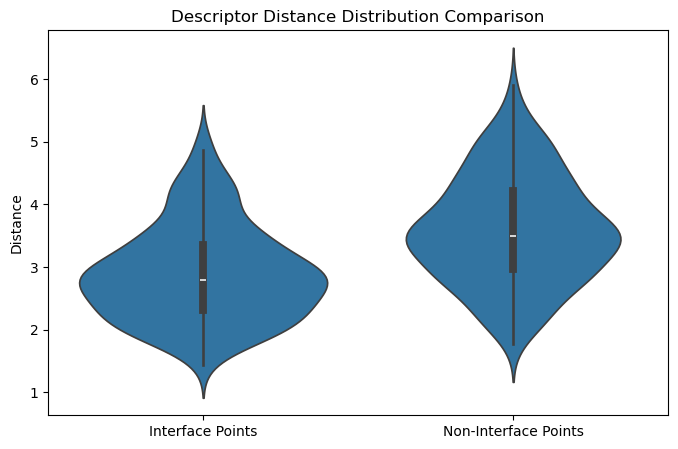

In [11]:
# plot a violin plot of the interface_points["distance"] and non_interface_points["distance"] using matplotlib for a static plot
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for seaborn
import pandas as pd
violin_data = pd.DataFrame({
    'distance': pd.concat([interface_points["distance"], non_interface_points["distance"]], ignore_index=True),
    'Type': ['Interface Points'] * len(interface_points) + ['Non-Interface Points'] * len(non_interface_points)
})

plt.figure(figsize=(8,5))
sns.violinplot(x='Type', y='distance', data=violin_data)
plt.title('Descriptor Distance Distribution Comparison')
plt.ylabel('Distance')
plt.xlabel('')
plt.show()